# Is the starter model orientation-dependent?

UCI-HAR was recorded with the phone on the **waist**, in one fixed orientation.
We build a per-axis model with **his model (RBF SVM)**, get it above 90%, then rotate the phone and re-test.
If the score drops, the model depends on how the phone is held.

In [4]:
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

base = "../Dataset/UCI HAR Dataset"
sigs = ["body_acc_x", "body_acc_y", "body_acc_z",
        "body_gyro_x", "body_gyro_y", "body_gyro_z",
        "total_acc_x", "total_acc_y", "total_acc_z"]

def load(split):
    # each file is (windows, 128 samples). stack the 9 raw signals.
    arrs = [np.loadtxt(f"{base}/{split}/Inertial Signals/{s}_{split}.txt") for s in sigs]
    return np.stack(arrs, axis=1)   # (windows, 9, 128)

Xtr_raw = load("train")
Xte_raw = load("test")
ytr = np.loadtxt(f"{base}/train/y_train.txt").astype(int)
yte = np.loadtxt(f"{base}/test/y_test.txt").astype(int)
print("train", Xtr_raw.shape, "  test", Xte_raw.shape)

train (7352, 9, 128)   test (2947, 9, 128)


In [5]:
# Per-axis features (X, Y, Z kept separate) - same family as his 561 features.
# These all change when the phone is rotated.
def features(X):
    time = [X.mean(2), X.std(2), X.min(2), X.max(2),
            np.median(X, 2), (X**2).mean(2),
            np.percentile(X, 75, 2) - np.percentile(X, 25, 2)]
    parts = [np.concatenate(time, axis=1)]

    # correlation between the axes of each sensor
    pairs = [(0,1),(0,2),(1,2),(3,4),(3,5),(4,5),(6,7),(6,8),(7,8)]
    for a, b in pairs:
        xa = X[:,a] - X[:,a].mean(1, keepdims=True)
        xb = X[:,b] - X[:,b].mean(1, keepdims=True)
        c = (xa*xb).sum(1) / (np.sqrt((xa**2).sum(1) * (xb**2).sum(1)) + 1e-9)
        parts.append(c[:, None])

    # frequency content of each axis
    F = np.abs(np.fft.rfft(X, axis=2))
    bins = np.arange(F.shape[2])
    Fn = F / (F.sum(2, keepdims=True) + 1e-9)
    dom = bins[np.argmax(F[:, :, 1:], axis=2) + 1]
    meanf = (Fn * bins).sum(2)
    energy = (F**2).mean(2)
    parts += [dom, meanf, energy]

    return np.concatenate(parts, axis=1)

Xtr = features(Xtr_raw)
Xte = features(Xte_raw)
print("features per window:", Xtr.shape[1])

features per window: 99


In [6]:
# His model: RBF SVM (his best, 97.93% on the full 561 features).
scaler = StandardScaler().fit(Xtr)
clf = SVC(kernel="rbf").fit(scaler.transform(Xtr), ytr)

clean_acc = accuracy_score(yte, clf.predict(scaler.transform(Xte)))
print("clean test accuracy:", round(clean_acc, 4))

clean test accuracy: 0.922


## Now rotate the phone

Give each test window a random 3D orientation (phone worn at any angle, not just on the waist).
Rotation is real motion, so we apply it to the raw signals, then recompute the same features.

In [7]:
def rotate(X, seed=0):
    R = Rotation.random(X.shape[0], random_state=seed).as_matrix()   # one orientation per window
    Xr = X.copy()
    # accel, gyro and total-accel are all measured in the phone frame -> same rotation
    for g in (slice(0, 3), slice(3, 6), slice(6, 9)):
        Xr[:, g, :] = np.einsum("wij,wjt->wit", R, X[:, g, :])
    return Xr

Xte_rot = features(rotate(Xte_raw, seed=0))
rot_acc = accuracy_score(yte, clf.predict(scaler.transform(Xte_rot)))
print("clean test accuracy  :", round(clean_acc, 4))
print("rotated test accuracy:", round(rot_acc, 4))
print("drop                 :", round(clean_acc - rot_acc, 4))

clean test accuracy  : 0.922
rotated test accuracy: 0.2664
drop                 : 0.6556


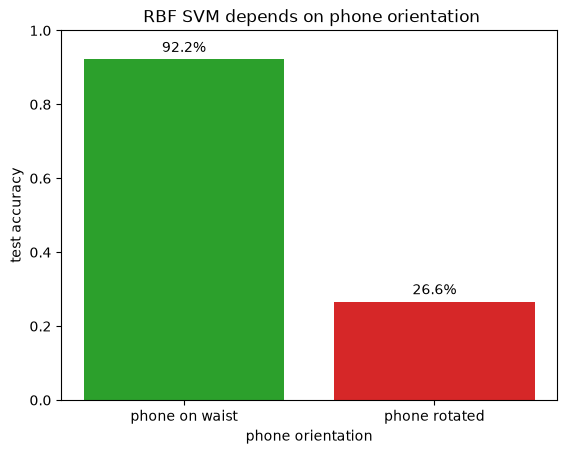

In [9]:
plt.bar(["phone on waist", "phone rotated"], [clean_acc, rot_acc],
        color=["tab:green", "tab:red"])
plt.ylabel("test accuracy")
plt.xlabel("phone orientation")
plt.title(" RBF SVM depends on phone orientation")
plt.ylim(0, 1)
for i, v in enumerate([clean_acc, rot_acc]):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.show()